# Evaluation & Analysis

Evaluates encoder (XLM-RoBERTa) and LLM predictions

**Research Questions**
- **RQ1** How does implicit vs explicit hate detection differ across languages? (encoder baseline)
- **RQ2** Does generating explanations improve classification, especially on implicit hate?
- **RQ3** How do multiple LLMs + demo-selection strategies compare across languages?

**Statistical tests**
- Chi-square / Mann–Whitney U  — compare accuracy rates on different example groups (RQ1)
- McNemar's test              — paired comparison of two conditions on same examples (RQ2 explanation effect, RQ3 demo strategy)
- Friedman + Wilcoxon          — k-way repeated-measures across models (RQ3)
- Point-biserial r             — BERTScore groundedness vs correctness correlation (RQ2.3)

In [1]:
# Setup: Local / Google Colab
import sys, os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    # Uploaded results to "My Drive/NLP4S-Toxicity-Detection/"
    DRIVE_PATH = "/content/drive/MyDrive/NLP4S-Toxicity-Detection"  # ← EDIT IF NEEDED

    os.chdir(DRIVE_PATH)
    os.system("pip install -q -r requirements.txt")
    os.system("pip install -q -e .")
    print(f"[Colab] working directory: {os.getcwd()}")
    print("[Colab] packages installed.")
else:
    print(f"[local] working directory: {Path.cwd()}")


Mounted at /content/drive
[Colab] working directory: /content/drive/MyDrive/NLP4S-Toxicity-Detection
[Colab] packages installed.


In [2]:
import json
import sys
import warnings
from itertools import combinations
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

try:
    _JUPYTER = True
    get_ipython
except NameError:
    _JUPYTER = False
    import matplotlib
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, precision_score, recall_score
from scipy.stats import chi2_contingency, wilcoxon, friedmanchisquare, pointbiserialr
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.contingency_tables import mcnemar as _mcnemar_fn

warnings.filterwarnings("ignore")

try:
    from IPython.display import display
except ImportError:
    display = lambda df: print(df.to_string())

try:
    _HERE = Path(__file__).resolve().parent
except NameError:
    _HERE = Path().resolve()

PROJECT_ROOT = _HERE
for _base in [_HERE, _HERE.parent]:
    if (_base / "src").exists():
        sys.path.insert(0, str(_base / "src"))
        PROJECT_ROOT = _base
        break

from nlp4s.functionalities import group_of, MHC_LANGUAGES, EXPLICIT, IMPLICIT, CONTROL
from nlp4s.io_utils import read_jsonl, read_predictions
from nlp4s.llm.prompts import PARSE_FAILURE_RATIONALE

sns.set_theme(style="whitegrid", palette="colorblind", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 130})
print("Imports done, project root:", PROJECT_ROOT)

Imports done, project root: /content/drive/MyDrive/NLP4S-Toxicity-Detection


## 1. Configuration

In [3]:
MHC_PATH      = PROJECT_ROOT / "data/processed/mhc.jsonl"
ENC_PRED_PATH = PROJECT_ROOT / "outputs/encoder_out/predictions.jsonl"
LLM_PRED_PATH = PROJECT_ROOT / "outputs/llm/predictions.jsonl"

OUTPUT_DIR  = PROJECT_ROOT / "outputs/eval"
FIGURES_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

LABEL_POS   = "hateful"
FUNC_ORDER  = ["derog_neg_attrib_h", "derog_dehum_h", "slur_h",
               "profanity_h", "derog_impl_h", "profanity_nh"]
GROUP_ORDER = ["explicit", "implicit", "control"]
LANG_ORDER  = list(MHC_LANGUAGES)          # ('ar','nl','fr','de','hi','it','zh','pl','pt','es','en')
MODEL_ORDER = ["aya-23", "llama-3-8b", "mistral-7b"]
SEL_ORDER   = ["random", "bm25", "target_group"]
COND_ORDER  = ["no_explanation", "explanation"]

GROUP_COLORS = {"explicit": "#2196F3", "implicit": "#FF5722", "control": "#4CAF50"}
COND_COLORS  = {"no_explanation": "#546E7A", "explanation": "#E91E63"}
MODEL_COLORS = {"aya-23": "#9C27B0", "llama-3-8b": "#FF9800", "mistral-7b": "#009688"}

print("Config set. Output: ", OUTPUT_DIR)

Config set. Output:  /content/drive/MyDrive/NLP4S-Toxicity-Detection/outputs/eval


## 2. Load Data & Build DataFrames

In [4]:
gold_examples = read_jsonl(str(MHC_PATH))
gold = {e.id: e for e in gold_examples}
enc_preds = read_predictions(str(ENC_PRED_PATH))
llm_preds = read_predictions(str(LLM_PRED_PATH))

print(f"Gold MHC   : {len(gold_examples):,} examples | {len({e.language for e in gold_examples})} languages")
print(f"Encoder    : {len(enc_preds):,} predictions")
print(f"LLM        : {len(llm_preds):,} predictions")


def build_df(predictions, gold_map):
    rows = []
    for p in predictions:
        e = gold_map.get(p.example_id)
        if e is None:
            continue
        try:
            grp = group_of(e.functionality)
        except KeyError:
            grp = "other"
        model_base, _, sel = p.model.partition("::")
        parse_fail = bool(p.rationale and PARSE_FAILURE_RATIONALE in p.rationale)
        rows.append({
            "example_id": p.example_id,
            "model":      model_base,
            "selection":  sel if sel else "encoder",
            "condition":  p.condition if p.condition else "encoder",
            "pred_label": p.pred_label,
            "rationale":  None if parse_fail else p.rationale,
            "parse_fail": parse_fail,
            "gold_label": e.label,
            "language":   e.language,
            "functionality": e.functionality,
            "group":      grp,
            "correct":    int(p.pred_label == e.label),
        })
    return pd.DataFrame(rows)


enc_df = build_df(enc_preds, gold)
llm_df = build_df(llm_preds, gold)

print(f"\nEncoder DF : {enc_df.shape}  | languages covered: {sorted(enc_df['language'].unique())}")
print(f"LLM DF     : {llm_df.shape}")
print(f"  models     : {sorted(llm_df['model'].unique())}")
print(f"  conditions : {sorted(llm_df['condition'].unique())}")
print(f"  selections : {sorted(llm_df['selection'].unique())}")
print(f"  parse fails: {llm_df['parse_fail'].sum()} ({100*llm_df['parse_fail'].mean():.1f}%)")

# Languages covered by encoder (subset of 7 from all 11)
ENC_LANGS = sorted(enc_df["language"].unique())

Gold MHC   : 8,806 examples | 11 languages
Encoder    : 5,528 predictions
LLM        : 9,504 predictions

Encoder DF : (5528, 12)  | languages covered: ['ar', 'de', 'en', 'es', 'fr', 'hi', 'zh']
LLM DF     : (9504, 12)
  models     : ['aya-23', 'llama-3-8b', 'mistral-7b']
  conditions : ['explanation', 'no_explanation']
  selections : ['bm25', 'random', 'target_group']
  parse fails: 0 (0.0%)


## 3. Helper Functions

In [5]:
def compute_metrics(df, label_pos=LABEL_POS):
    n = len(df)
    if n == 0:
        return {"f1": np.nan, "precision": np.nan, "recall": np.nan, "accuracy": np.nan, "n": 0}
    yt = df["gold_label"].values
    yp = df["pred_label"].values
    return {
        "f1":        f1_score(yt, yp, pos_label=label_pos, zero_division=0),
        "precision": precision_score(yt, yp, pos_label=label_pos, zero_division=0),
        "recall":    recall_score(yt, yp, pos_label=label_pos, zero_division=0),
        "accuracy":  float((yt == yp).mean()),
        "n":         n,
    }


def metrics_table(df, group_cols):
    if isinstance(group_cols, str):
        group_cols = [group_cols]
    rows = []
    for keys, grp in df.groupby(group_cols, sort=False):
        m = compute_metrics(grp)
        row = dict(zip(group_cols, keys if isinstance(keys, tuple) else [keys]))
        row.update(m)
        rows.append(row)
    return pd.DataFrame(rows)


def pivot_f1(df, index_col, columns_col, round_d=3):
    mt = metrics_table(df, [index_col, columns_col])
    return mt.pivot(index=index_col, columns=columns_col, values="f1").round(round_d)


def save_fig(name, tight=True):
    path = FIGURES_DIR / f"{name}.png"
    if tight:
        plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    if _JUPYTER:
        plt.show()
    else:
        plt.close()
    print(f"  [saved] {path.relative_to(PROJECT_ROOT)}")


def run_mcnemar(df_base, df_test):
    """Paired McNemar test on shared example_ids between two prediction frames."""
    merged = (
        df_base[["example_id", "correct"]]
        .merge(df_test[["example_id", "correct"]], on="example_id", suffixes=("_b", "_t"))
    )
    n00 = int(((merged["correct_b"] == 0) & (merged["correct_t"] == 0)).sum())
    n01 = int(((merged["correct_b"] == 0) & (merged["correct_t"] == 1)).sum())
    n10 = int(((merged["correct_b"] == 1) & (merged["correct_t"] == 0)).sum())
    n11 = int(((merged["correct_b"] == 1) & (merged["correct_t"] == 1)).sum())
    if (n01 + n10) == 0:
        return {"stat": np.nan, "pvalue": np.nan, "n00": n00, "n01": n01, "n10": n10, "n11": n11, "n": len(merged)}
    table = np.array([[n00, n01], [n10, n11]])
    res = _mcnemar_fn(table, exact=False, correction=True)
    return {"stat": round(float(res.statistic), 4), "pvalue": round(float(res.pvalue), 6),
            "n00": n00, "n01": n01, "n10": n10, "n11": n11, "n": len(merged)}


def sig_stars(p):
    if np.isnan(p): return "—"
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."


print("Helper functions defined.")

Helper functions defined.


## Section 1 — RQ1: Encoder (XLM-RoBERTa) Baseline

### 1.1 Overall Metrics

In [6]:
overall = compute_metrics(enc_df)
print("=" * 52)
print("  XLM-RoBERTa Overall Performance on MHC")
print("=" * 52)
for k in ["f1", "precision", "recall", "accuracy"]:
    print(f"  {k:<12}: {overall[k]:.4f}")
print(f"  {'n':<12}: {overall['n']:,}")

  XLM-RoBERTa Overall Performance on MHC
  f1          : 0.7749
  precision   : 0.9002
  recall      : 0.6802
  accuracy    : 0.6548
  n           : 5,528


### 1.2 Performance by Functionality Group

=== Encoder: Metrics by Functionality Group ===


,f1,precision,recall,accuracy,n
group,,,,,
explicit,0.8635,1.0,0.7598,0.7598,3838
implicit,0.5420,1.0,0.3717,0.3717,990
control,0.0000,0.0,0.0000,0.4800,700


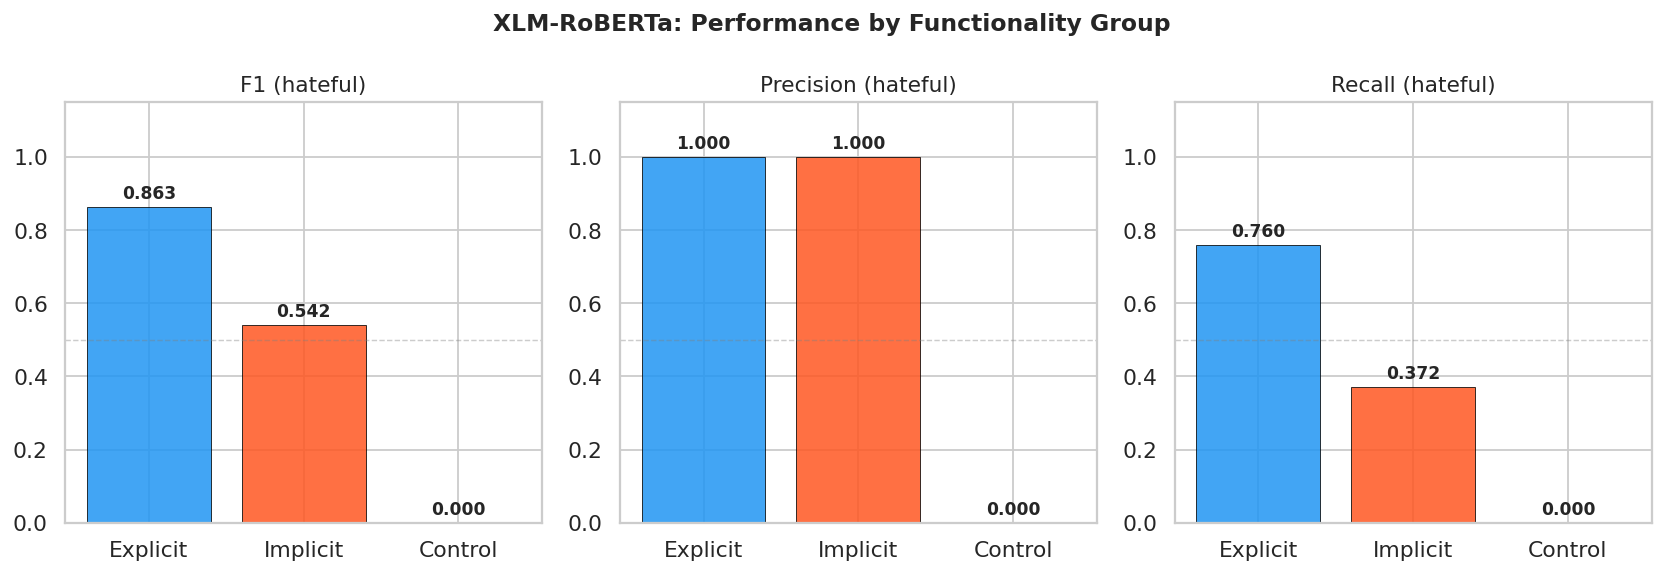

  [saved] outputs/eval/figures/rq1_encoder_by_group.png

=== Pooled Group F1 (hate group + control as negative class) ===
  Specificity (control): 0.4800  — 336/700 non-hateful examples correctly not flagged.


,group,f1_pooled,precision_pooled,recall,specificity_ctrl
0,explicit,0.8193,0.8890,0.7598,0.48
1,implicit,0.4274,0.5027,0.3717,0.48


In [7]:
grp_df = metrics_table(enc_df, "group")
grp_df = grp_df.set_index("group").reindex(GROUP_ORDER)

print("=== Encoder: Metrics by Functionality Group ===")
display(grp_df[["f1", "precision", "recall", "accuracy", "n"]].round(4))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=False)
for ax, (metric, label) in zip(axes, [("f1", "F1"), ("precision", "Precision"), ("recall", "Recall")]):
    vals = [grp_df.loc[g, metric] for g in GROUP_ORDER]
    colors = [GROUP_COLORS[g] for g in GROUP_ORDER]
    bars = ax.bar(GROUP_ORDER, vals, color=colors, alpha=0.85, edgecolor="black", linewidth=0.5)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.012,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=9.5, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.set_title(f"{label} (hateful)", fontsize=12)
    ax.set_xticklabels([g.capitalize() for g in GROUP_ORDER])
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.4, linewidth=0.8)

fig.suptitle("XLM-RoBERTa: Performance by Functionality Group", fontsize=13, fontweight="bold")
save_fig("rq1_encoder_by_group")

# Pooled group F1 (addresses single-class degeneracy)
_ctrl_enc = enc_df[enc_df["group"] == "control"]
_pooled_rows = []
for _grp in ["explicit", "implicit"]:
    _hate = enc_df[enc_df["group"] == _grp]
    _pooled = pd.concat([_hate, _ctrl_enc], ignore_index=True)
    _m = compute_metrics(_pooled)
    _spec = float((_ctrl_enc["pred_label"] != LABEL_POS).mean())
    _pooled_rows.append({
        "group": _grp,
        "f1_pooled": round(_m["f1"], 4),
        "precision_pooled": round(_m["precision"], 4),
        "recall": round(_m["recall"], 4),
        "specificity_ctrl": round(_spec, 4),
    })
pooled_grp_df = pd.DataFrame(_pooled_rows)
print("\n=== Pooled Group F1 (hate group + control as negative class) ===")
_spec_overall = float((_ctrl_enc["pred_label"] != LABEL_POS).mean())
print(f"  Specificity (control): {_spec_overall:.4f}  "
      f"— {int((_ctrl_enc['pred_label'] != LABEL_POS).sum())}/{len(_ctrl_enc)} "
      "non-hateful examples correctly not flagged.")
display(pooled_grp_df)

### 1.3 Performance by Language

=== Encoder: Metrics by Language ===


,f1,precision,recall,accuracy,n
language,,,,,
ar,0.7868,0.9168,0.6890,0.6759,756
de,0.6804,0.8759,0.5562,0.5439,785
en,0.8144,0.8644,0.7699,0.6928,804
es,0.7836,0.9137,0.6859,0.6679,810
fr,0.8651,0.9063,0.8275,0.7737,813
hi,0.5947,0.8975,0.4446,0.4747,750
zh,0.8373,0.9250,0.7648,0.7395,810


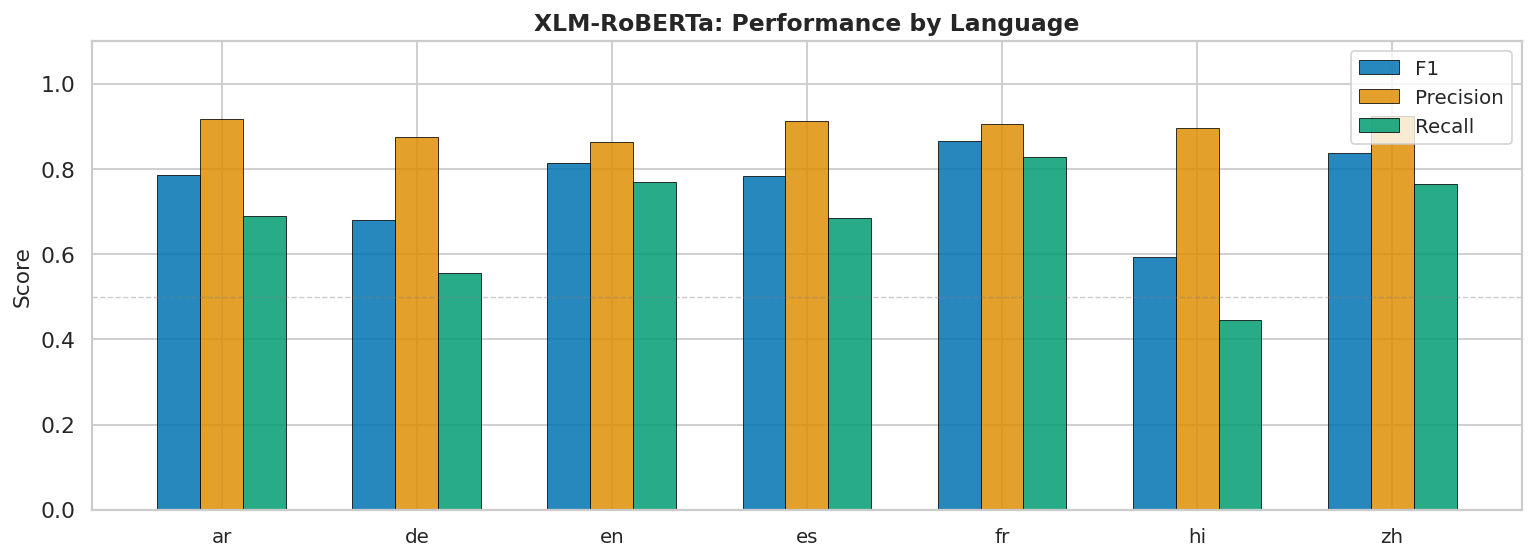

  [saved] outputs/eval/figures/rq1_encoder_by_language.png


In [8]:
lang_df = metrics_table(enc_df, "language")
lang_df = lang_df.set_index("language").reindex(ENC_LANGS)

print("=== Encoder: Metrics by Language ===")
display(lang_df[["f1", "precision", "recall", "accuracy", "n"]].round(4))

fig, ax = plt.subplots(figsize=(12, 4.5))
x = np.arange(len(ENC_LANGS))
w = 0.22
for i, (metric, label) in enumerate([("f1", "F1"), ("precision", "Precision"), ("recall", "Recall")]):
    vals = [lang_df.loc[l, metric] if l in lang_df.index else np.nan for l in ENC_LANGS]
    ax.bar(x + (i - 1) * w, vals, width=w, label=label, alpha=0.85, edgecolor="black", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(ENC_LANGS, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("XLM-RoBERTa: Performance by Language", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.4, linewidth=0.8)
save_fig("rq1_encoder_by_language")

### 1.4 F1 Heatmap — Functionality × Language

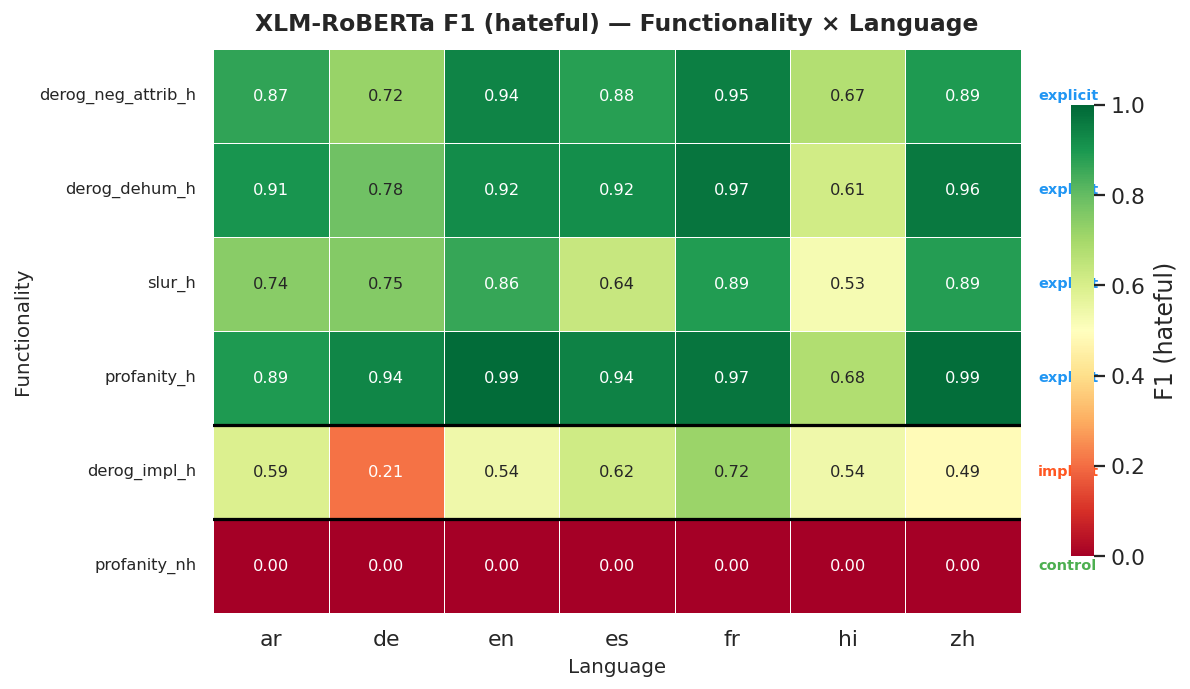

  [saved] outputs/eval/figures/rq1_encoder_heatmap_func_lang.png


In [9]:
piv_enc = pivot_f1(enc_df, index_col="functionality", columns_col="language")
piv_enc = piv_enc.reindex(index=FUNC_ORDER, columns=ENC_LANGS)

fig, ax = plt.subplots(figsize=(max(9, len(ENC_LANGS) * 1.1 + 2), 5.5))
sns.heatmap(
    piv_enc, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=0.4, ax=ax, annot_kws={"size": 9},
    cbar_kws={"label": "F1 (hateful)", "shrink": 0.8},
    mask=piv_enc.isna(),
)
# Group divider lines (after explicit rows = 4, after implicit = 5)
ax.axhline(4, color="black", linewidth=1.8)
ax.axhline(5, color="black", linewidth=1.8)
ax.set_title("XLM-RoBERTa F1 (hateful) — Functionality × Language", fontsize=13, fontweight="bold", pad=10)
ax.set_xlabel("Language", fontsize=11)
ax.set_ylabel("Functionality", fontsize=11)
ax.set_yticklabels(FUNC_ORDER, rotation=0, fontsize=9)

# Group labels on right
group_map = {f: group_of(f) for f in FUNC_ORDER}
for i, func in enumerate(FUNC_ORDER):
    grp = group_map[func]
    ax.text(len(ENC_LANGS) + 0.15, i + 0.5, grp, va="center", fontsize=8,
            color=GROUP_COLORS.get(grp, "black"), fontweight="bold")

save_fig("rq1_encoder_heatmap_func_lang")

### 1.5 Statistical Tests: Implicit vs Explicit Gap (RQ1)

  RQ1 Statistical Tests — Implicit vs Explicit Gap
  Test: Chi-square on contingency table [correct/wrong x group]
  implicit vs explicit:
    Accuracy: implicit=0.3717 (n=990), explicit=0.7598 (n=3838)
    Chi2: chi2=544.804, p=1.6996e-120 ***  (phi=0.3359)
  implicit vs control:
    Accuracy: implicit=0.3717 (n=990), control=0.4800 (n=700)
    Chi2: chi2=19.783, p=8.6756e-06 ***  (phi=0.1082)
  explicit vs control:
    Accuracy: explicit=0.7598 (n=3838), control=0.4800 (n=700)
    Chi2: chi2=228.182, p=1.4857e-51 ***  (phi=0.2242)

  Per-language F1 gap (implicit - explicit):


,f1_implicit,f1_explicit,gap
language,,,
de,0.2099,0.8053,-0.5954
zh,0.4865,0.9326,-0.4461
en,0.5417,0.9298,-0.3881
ar,0.5922,0.8670,-0.2747
es,0.6207,0.8531,-0.2324
fr,0.7156,0.9438,-0.2282
hi,0.5417,0.6345,-0.0929


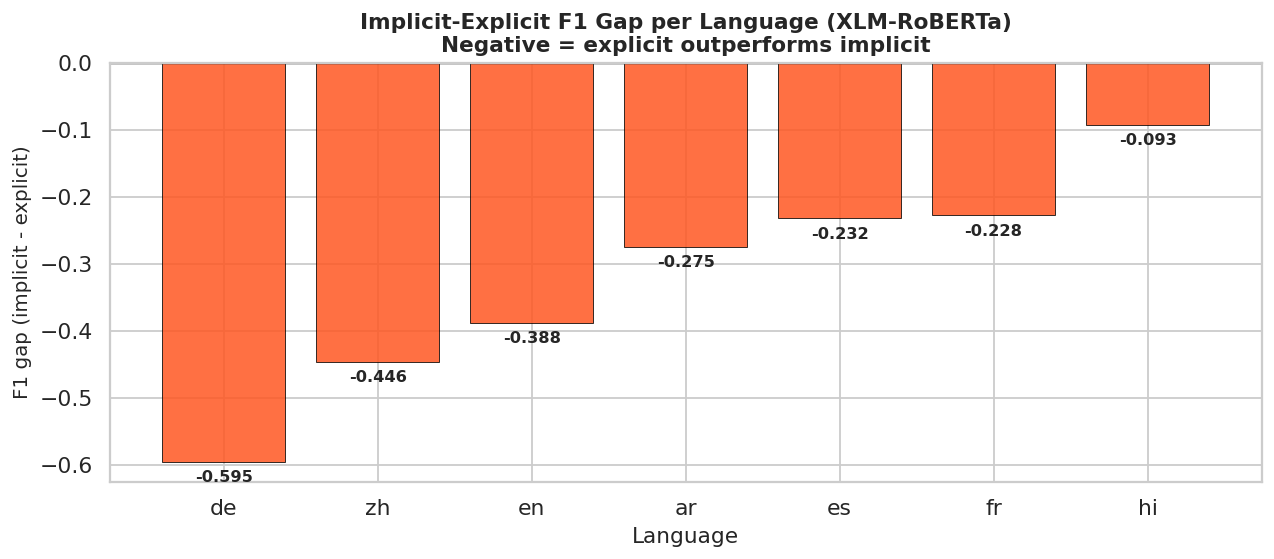

  [saved] outputs/eval/figures/rq1_impl_expl_gap_by_language.png


In [10]:
print("=" * 65)
print("  RQ1 Statistical Tests — Implicit vs Explicit Gap")
print("=" * 65)
print("  Test: Chi-square on contingency table [correct/wrong x group]")

stat_rows = []
for grp_a, grp_b in [("implicit", "explicit"), ("implicit", "control"), ("explicit", "control")]:
    df_a = enc_df[enc_df["group"] == grp_a]
    df_b = enc_df[enc_df["group"] == grp_b]
    c_a, n_a = df_a["correct"].sum(), len(df_a)
    c_b, n_b = df_b["correct"].sum(), len(df_b)
    acc_a, acc_b = c_a / n_a, c_b / n_b
    table = np.array([[c_a, n_a - c_a], [c_b, n_b - c_b]])
    chi2, p_chi, _, _ = chi2_contingency(table, correction=False)
    phi = np.sqrt(chi2 / (n_a + n_b))
    print(f"  {grp_a} vs {grp_b}:")
    print(f"    Accuracy: {grp_a}={acc_a:.4f} (n={n_a}), {grp_b}={acc_b:.4f} (n={n_b})")
    print(f"    Chi2: chi2={chi2:.3f}, p={p_chi:.4e} {sig_stars(p_chi)}  (phi={phi:.4f})")
    stat_rows.append({"comparison": f"{grp_a} vs {grp_b}", "acc_a": round(acc_a, 4),
                       "acc_b": round(acc_b, 4), "chi2": round(chi2, 3), "p_chi2": round(p_chi, 6),
                       "phi": round(phi, 4), "sig_chi2": sig_stars(p_chi)})

stats_rq1 = pd.DataFrame(stat_rows)

# Per-language implicit-explicit F1 gap
print("\n  Per-language F1 gap (implicit - explicit):")
gap_rows = []
for lang in ENC_LANGS:
    sub = enc_df[enc_df["language"] == lang]
    f1_impl = compute_metrics(sub[sub["group"] == "implicit"])["f1"]
    f1_expl = compute_metrics(sub[sub["group"] == "explicit"])["f1"]
    gap_rows.append({"language": lang, "f1_implicit": round(f1_impl, 4),
                     "f1_explicit": round(f1_expl, 4), "gap": round(f1_impl - f1_expl, 4)})
gap_df = pd.DataFrame(gap_rows).set_index("language")
display(gap_df.sort_values("gap"))

# Gap bar chart
fig, ax = plt.subplots(figsize=(10, 4.5))
sorted_langs = gap_df.sort_values("gap").index.tolist()
gaps = [gap_df.loc[l, "gap"] for l in sorted_langs]
colors = ["#FF5722" if g < 0 else "#2196F3" for g in gaps]
bars = ax.bar(sorted_langs, gaps, color=colors, alpha=0.85, edgecolor="black", linewidth=0.5)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Language", fontsize=12)
ax.set_ylabel("F1 gap (implicit - explicit)", fontsize=11)
ax.set_title("Implicit-Explicit F1 Gap per Language (XLM-RoBERTa)\n"
             "Negative = explicit outperforms implicit", fontsize=12, fontweight="bold")
for bar, val in zip(bars, gaps):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + (0.003 if val >= 0 else -0.012),
            f"{val:+.3f}", ha="center", va="bottom" if val >= 0 else "top", fontsize=9, fontweight="bold")
save_fig("rq1_impl_expl_gap_by_language")

## Section 2 — RQ2: Does Explanation Prompting Help?

### 2.1 Explanation vs No-Explanation — Per Model, Per Group

In [11]:
# Full metrics table: model × selection × condition × group
detail_rows = []
for model in MODEL_ORDER:
    for sel in SEL_ORDER:
        for cond in COND_ORDER:
            sub = llm_df[(llm_df["model"] == model) &
                          (llm_df["selection"] == sel) &
                          (llm_df["condition"] == cond)]
            if len(sub) == 0:
                continue
            for grp in GROUP_ORDER:
                mg = compute_metrics(sub[sub["group"] == grp])
                detail_rows.append({
                    "model": model, "selection": sel, "condition": cond, "group": grp,
                    **{k: round(v, 4) for k, v in mg.items()},
                })
detail_df = pd.DataFrame(detail_rows)

# Aggregate over selection strategies (mean) for cleaner comparison
summ = (detail_df.groupby(["model", "condition", "group"])
        [["f1", "precision", "recall", "accuracy"]].mean().round(4).reset_index())

piv_rq2 = summ.pivot_table(index=["model", "condition"], columns="group", values="f1")[GROUP_ORDER]
print("=== LLM: Mean F1 by model × condition × group (avg over selection strategies) ===")
display(piv_rq2.round(4))

=== LLM: Mean F1 by model × condition × group (avg over selection strategies) ===


group                      explicit  implicit  control
model      condition                                  
aya-23     explanation       0.9777    0.9541      0.0
           no_explanation    0.9652    0.9394      0.0
llama-3-8b explanation       0.9368    0.9479      0.0
           no_explanation    0.9341    0.9565      0.0
mistral-7b explanation       0.9224    0.8881      0.0
           no_explanation    0.9174    0.8764      0.0

### 2.2 Explanation Effect Delta Chart

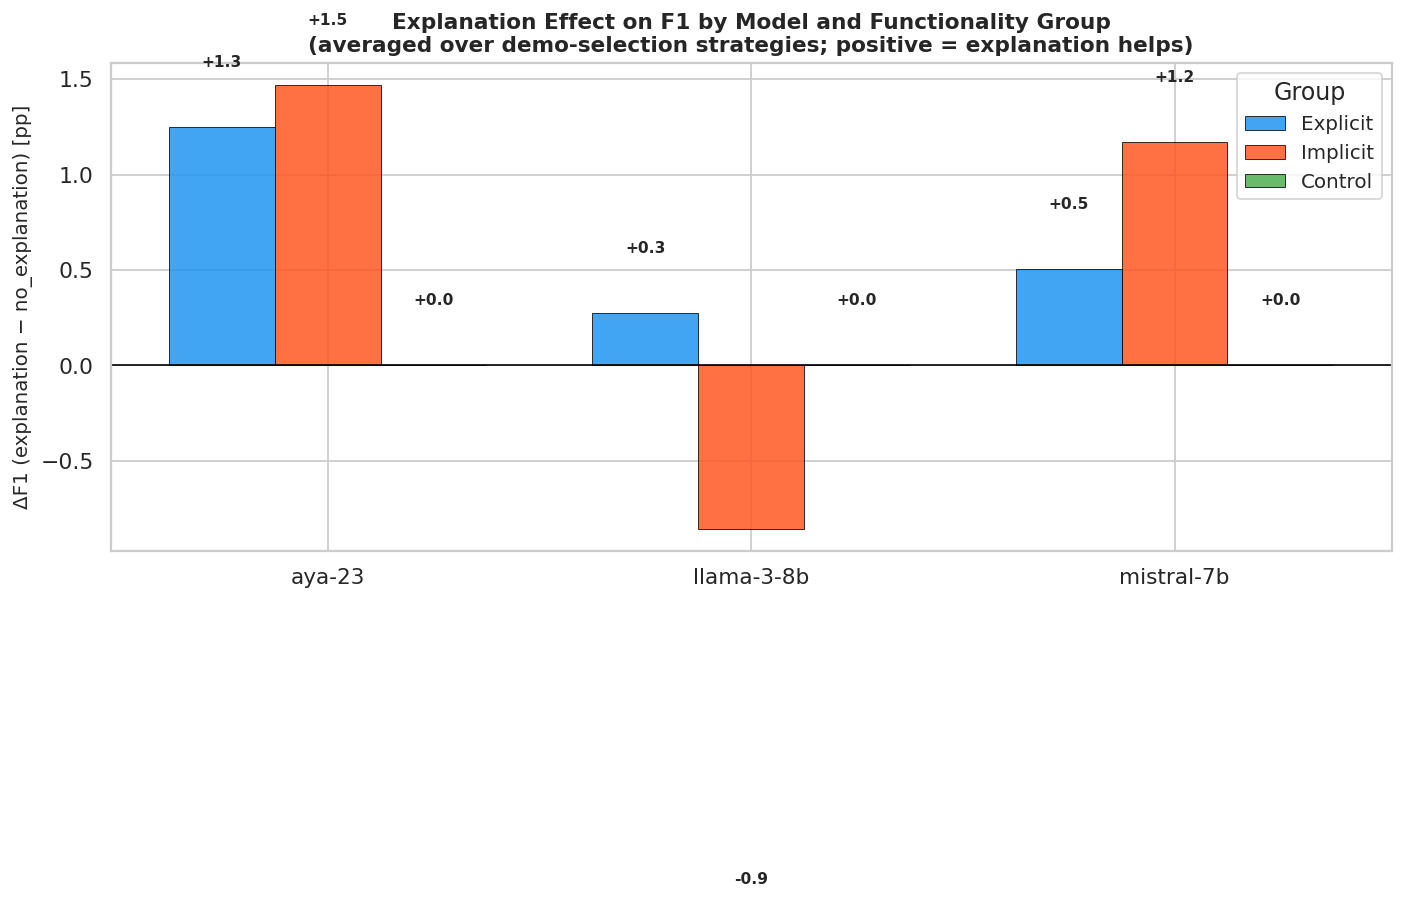

  [saved] outputs/eval/figures/rq2_explanation_delta_by_group.png

=== Explanation Effect on Control Group (Specificity Regression) ===
  Mean delta_acc (explanation - no_explanation) for control group:


,model,delta_accuracy_control
0,aya-23,-0.087121
1,llama-3-8b,-0.018939
2,mistral-7b,-0.018939


  Negative values = explanation prompting increases false-positive rate on non-hateful text.


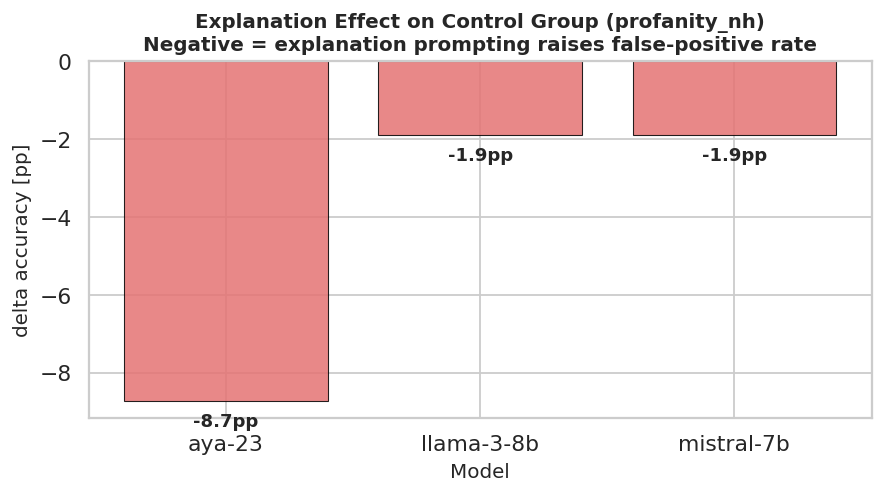

  [saved] outputs/eval/figures/rq2_explanation_delta_acc_control.png


In [12]:
delta_rows = []
for model in MODEL_ORDER:
    for sel in SEL_ORDER:
        base = llm_df[(llm_df["model"] == model) & (llm_df["selection"] == sel) & (llm_df["condition"] == "no_explanation")]
        test = llm_df[(llm_df["model"] == model) & (llm_df["selection"] == sel) & (llm_df["condition"] == "explanation")]
        if len(base) == 0 or len(test) == 0:
            continue
        for grp in GROUP_ORDER:
            f1_base = compute_metrics(base[base["group"] == grp])["f1"]
            f1_test = compute_metrics(test[test["group"] == grp])["f1"]
            acc_base = compute_metrics(base[base["group"] == grp])["accuracy"]
            acc_test = compute_metrics(test[test["group"] == grp])["accuracy"]
            delta_rows.append({"model": model, "selection": sel, "group": grp,
                                 "delta_f1": f1_test - f1_base,
                                 "delta_acc": acc_test - acc_base,
                                 "f1_no_expl": f1_base, "f1_expl": f1_test})
delta_df = pd.DataFrame(delta_rows)

# Mean delta by model × group
mean_delta = delta_df.groupby(["model", "group"])["delta_f1"].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 10))
x = np.arange(len(MODEL_ORDER))
w = 0.25
for i, grp in enumerate(GROUP_ORDER):
    sub = mean_delta[mean_delta["group"] == grp].set_index("model").reindex(MODEL_ORDER)
    vals = sub["delta_f1"].values * 100  # convert to percentage points
    bars = ax.bar(x + (i - 1) * w, vals, width=w, label=grp.capitalize(),
                   color=GROUP_COLORS[grp], alpha=0.85, edgecolor="black", linewidth=0.5)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            offset = 0.3 if val >= 0 else -1.8
            va = "bottom" if val >= 0 else "top"
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + offset,
                    f"{val:+.1f}", ha="center", va=va, fontsize=8.5, fontweight="bold")
ax.axhline(0, color="black", linewidth=0.9)
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=12)
ax.set_ylabel("ΔF1 (explanation − no_explanation) [pp]", fontsize=11)
ax.set_title("Explanation Effect on F1 by Model and Functionality Group\n"
             "(averaged over demo-selection strategies; positive = explanation helps)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=11, title="Group")
save_fig("rq2_explanation_delta_by_group")

# delta_acc for control
print("\n=== Explanation Effect on Control Group (Specificity Regression) ===")
ctrl_delta = delta_df[delta_df["group"] == "control"].groupby("model")["delta_acc"].mean().reset_index()
print("  Mean delta_acc (explanation - no_explanation) for control group:")
display(ctrl_delta.rename(columns={"delta_acc": "delta_accuracy_control"}))
print("  Negative values = explanation prompting increases false-positive rate on non-hateful text.")

fig2, ax2 = plt.subplots(figsize=(7, 4))
colors_m = [GROUP_COLORS.get(m, "#888") for m in ctrl_delta["model"]]
bars2 = ax2.bar(ctrl_delta["model"], ctrl_delta["delta_acc"] * 100,
                color="#E57373", alpha=0.85, edgecolor="black", linewidth=0.6)
for bar, val in zip(bars2, ctrl_delta["delta_acc"] * 100):
    va = "top" if val < 0 else "bottom"
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + (-0.3 if val < 0 else 0.3),
             f"{val:+.1f}pp", ha="center", va=va, fontsize=10, fontweight="bold")
ax2.axhline(0, color="black", linewidth=0.9)
ax2.set_ylabel("delta accuracy [pp]", fontsize=11)
ax2.set_xlabel("Model", fontsize=11)
ax2.set_title("Explanation Effect on Control Group (profanity_nh)\n"
              "Negative = explanation prompting raises false-positive rate",
              fontsize=11, fontweight="bold")
save_fig("rq2_explanation_delta_acc_control")

### 2.3 McNemar Tests: Explanation vs No-Explanation (RQ2)

In [13]:
print("=" * 72)
print("  RQ2 McNemar Tests — Explanation vs No-Explanation")
print("  H0: error pattern is identical; H1: conditions produce different errors")
print("=" * 72)

mc_rows = []
for model in MODEL_ORDER:
    for sel in SEL_ORDER:
        base = llm_df[(llm_df["model"] == model) & (llm_df["selection"] == sel) & (llm_df["condition"] == "no_explanation")]
        test = llm_df[(llm_df["model"] == model) & (llm_df["selection"] == sel) & (llm_df["condition"] == "explanation")]
        for grp_filter in GROUP_ORDER + ["all"]:
            b = base if grp_filter == "all" else base[base["group"] == grp_filter]
            t = test if grp_filter == "all" else test[test["group"] == grp_filter]
            res = run_mcnemar(b, t)
            mc_rows.append({"model": model, "selection": sel, "group": grp_filter,
                             **res, "sig": sig_stars(res["pvalue"])})

mc_df = pd.DataFrame(mc_rows)


# Holm-Bonferroni correction across all McNemar comparisons
print("  Applying Holm-Bonferroni correction across all tested combinations.")
print("  Uncorrected p-values stored in pvalue_uncorr for reference.")
_valid = mc_df["pvalue"].notna()
if _valid.any():
    _, _pcorr, _, _ = multipletests(mc_df.loc[_valid, "pvalue"].values, method="holm")
    mc_df.loc[_valid, "pvalue_uncorr"] = mc_df.loc[_valid, "pvalue"]
    mc_df.loc[_valid, "pvalue"] = _pcorr.round(6)
    mc_df["sig"] = mc_df["pvalue"].apply(lambda p: sig_stars(p) if pd.notna(p) else "—")

for grp_filter in ["implicit", "all"]:
    sub = mc_df[mc_df["group"] == grp_filter][
        ["model", "selection", "stat", "pvalue", "n01", "n10", "sig"]
    ]
    print(f"\n  Group = '{grp_filter}' (n01 = expl improved, n10 = expl hurt)")
    display(sub.reset_index(drop=True))

  RQ2 McNemar Tests — Explanation vs No-Explanation
  H0: error pattern is identical; H1: conditions produce different errors
  Applying Holm-Bonferroni correction across all tested combinations.
  Uncorrected p-values stored in pvalue_uncorr for reference.

  Group = 'implicit' (n01 = expl improved, n10 = expl hurt)


,model,selection,stat,pvalue,n01,n10,sig
0,aya-23,random,0.5000,1.0,2,0,n.s.
1,aya-23,bm25,1.5000,1.0,5,1,n.s.
2,aya-23,target_group,0.0000,1.0,3,2,n.s.
3,llama-3-8b,random,0.0000,1.0,1,0,n.s.
4,llama-3-8b,bm25,0.8000,1.0,1,4,n.s.
5,llama-3-8b,target_group,0.2500,1.0,1,3,n.s.
6,mistral-7b,random,0.8000,1.0,4,1,n.s.
7,mistral-7b,bm25,0.1667,1.0,3,3,n.s.
8,mistral-7b,target_group,0.1250,1.0,5,3,n.s.



  Group = 'all' (n01 = expl improved, n10 = expl hurt)


,model,selection,stat,pvalue,n01,n10,sig
0,aya-23,random,0.1290,1.000000,14,17,n.s.
1,aya-23,bm25,0.8333,1.000000,18,12,n.s.
2,aya-23,target_group,1.0417,1.000000,15,9,n.s.
3,llama-3-8b,random,0.0000,1.000000,7,8,n.s.
4,llama-3-8b,bm25,0.0455,1.000000,11,11,n.s.
5,llama-3-8b,target_group,0.1905,1.000000,9,12,n.s.
6,mistral-7b,random,6.5000,0.366758,20,6,n.s.
7,mistral-7b,bm25,0.5000,1.000000,7,11,n.s.
8,mistral-7b,target_group,0.0000,1.000000,9,10,n.s.


### 2.4 Explanation Effect by Language

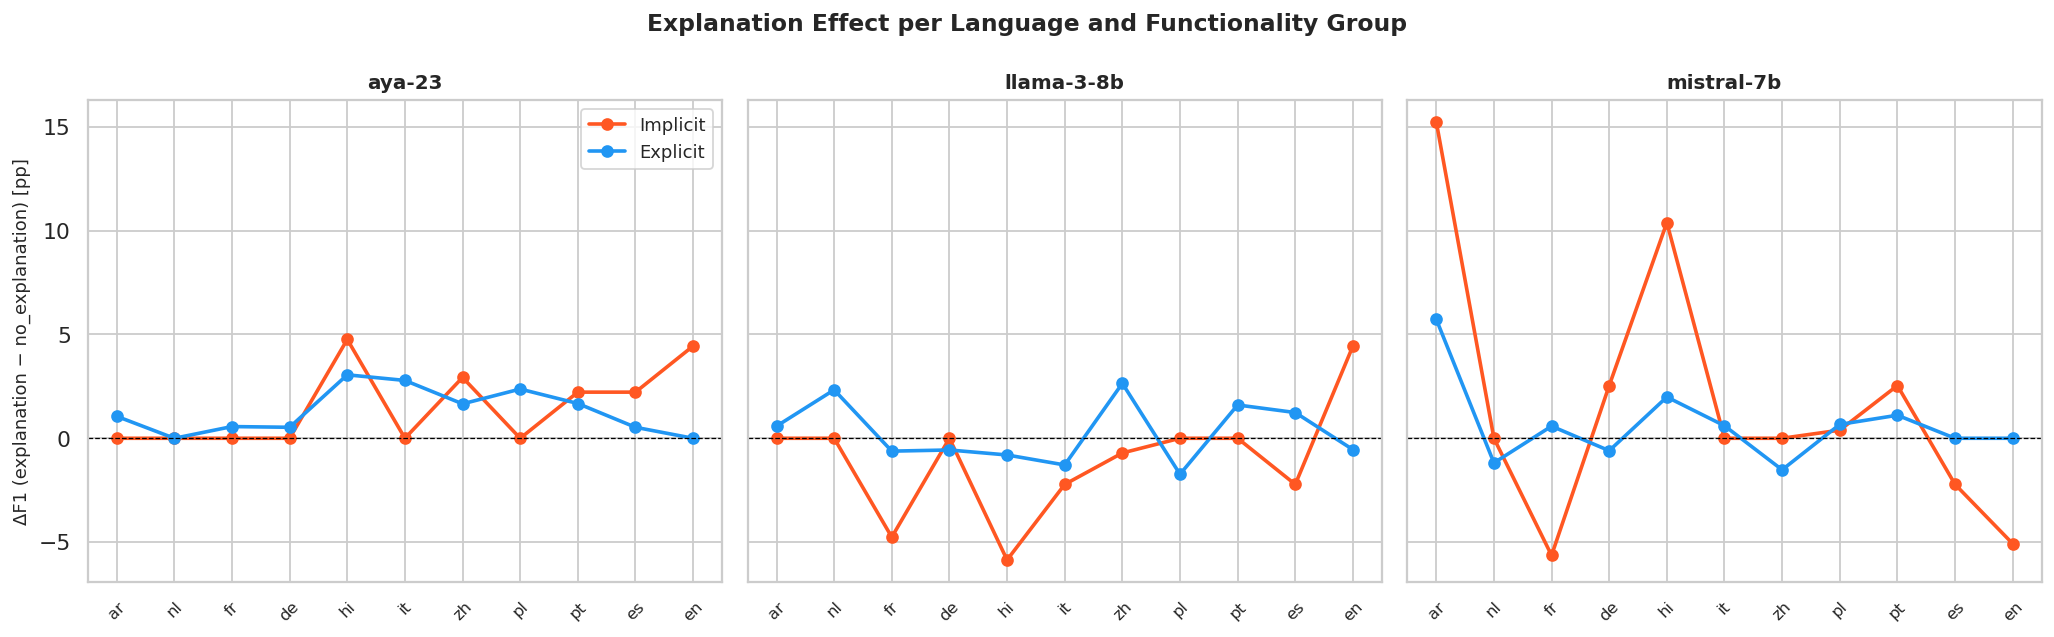

  [saved] outputs/eval/figures/rq2_explanation_delta_by_language.png


In [14]:
lang_delta_rows = []
for model in MODEL_ORDER:
    for sel in SEL_ORDER:
        for lang in LANG_ORDER:
            base = llm_df[(llm_df["model"] == model) & (llm_df["selection"] == sel) &
                           (llm_df["condition"] == "no_explanation") & (llm_df["language"] == lang)]
            test = llm_df[(llm_df["model"] == model) & (llm_df["selection"] == sel) &
                           (llm_df["condition"] == "explanation") & (llm_df["language"] == lang)]
            for grp in ["implicit", "explicit"]:
                f1_b = compute_metrics(base[base["group"] == grp])["f1"]
                f1_t = compute_metrics(test[test["group"] == grp])["f1"]
                lang_delta_rows.append({"model": model, "selection": sel, "language": lang,
                                          "group": grp, "delta_f1": f1_t - f1_b})
lang_delta_df = pd.DataFrame(lang_delta_rows)
mean_lang_delta = lang_delta_df.groupby(["model", "language", "group"])["delta_f1"].mean().reset_index()

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(16, 5), sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    for grp in ["implicit", "explicit"]:
        sub = mean_lang_delta[(mean_lang_delta["model"] == model) & (mean_lang_delta["group"] == grp)]
        sub = sub.set_index("language").reindex(LANG_ORDER)
        vals = sub["delta_f1"].values * 100
        x = np.arange(len(LANG_ORDER))
        ax.plot(x, vals, marker="o", label=grp.capitalize(), color=GROUP_COLORS[grp], linewidth=2)
    ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
    ax.set_title(model, fontsize=11, fontweight="bold")
    ax.set_xticks(np.arange(len(LANG_ORDER)))
    ax.set_xticklabels(LANG_ORDER, fontsize=9, rotation=45)
    if ax == axes[0]:
        ax.set_ylabel("ΔF1 (explanation − no_explanation) [pp]", fontsize=10)
        ax.legend(fontsize=10)

fig.suptitle("Explanation Effect per Language and Functionality Group", fontsize=13, fontweight="bold")
save_fig("rq2_explanation_delta_by_language")

## Section 3 — RQ3: Multi-model Cross-language Analysis

### 3.1 Model × Condition × Group Comparison Table

In [15]:
print("=== RQ3: LLM Model Comparison ===\n")
comp_rows = []
for model in MODEL_ORDER:
    for cond in COND_ORDER:
        sub = llm_df[(llm_df["model"] == model) & (llm_df["condition"] == cond)]
        m_all = compute_metrics(sub)
        for grp in GROUP_ORDER:
            mg = compute_metrics(sub[sub["group"] == grp])
            comp_rows.append({"model": model, "condition": cond, "group": grp,
                               "f1": round(mg["f1"], 4),
                               "accuracy": round(mg["accuracy"], 4), "n": mg["n"]})
comp_df = pd.DataFrame(comp_rows)

piv_comp = comp_df.pivot_table(index=["model", "condition"], columns="group", values="f1")[GROUP_ORDER]
display(piv_comp.round(4))

# Encoder row for comparison
enc_comp_rows = [{"model": "XLM-RoBERTa", "condition": "encoder", "group": grp,
                   "f1": round(compute_metrics(enc_df[enc_df["group"] == grp])["f1"], 4)}
                  for grp in GROUP_ORDER]
print("\n  Encoder (XLM-RoBERTa) reference:")
enc_comp_df = pd.DataFrame(enc_comp_rows).pivot(index=["model", "condition"], columns="group", values="f1")[GROUP_ORDER]
display(enc_comp_df.round(4))

=== RQ3: LLM Model Comparison ===



group                      explicit  implicit  control
model      condition                                  
aya-23     explanation       0.9777    0.9545      0.0
           no_explanation    0.9652    0.9398      0.0
llama-3-8b explanation       0.9371    0.9482      0.0
           no_explanation    0.9344    0.9565      0.0
mistral-7b explanation       0.9224    0.8884      0.0
           no_explanation    0.9175    0.8766      0.0


  Encoder (XLM-RoBERTa) reference:


,group,explicit,implicit,control
model,condition,,,
XLM-RoBERTa,encoder,0.8635,0.542,0.0


### 3.2 Model × Language Heatmap (F1 — implicit and explicit)

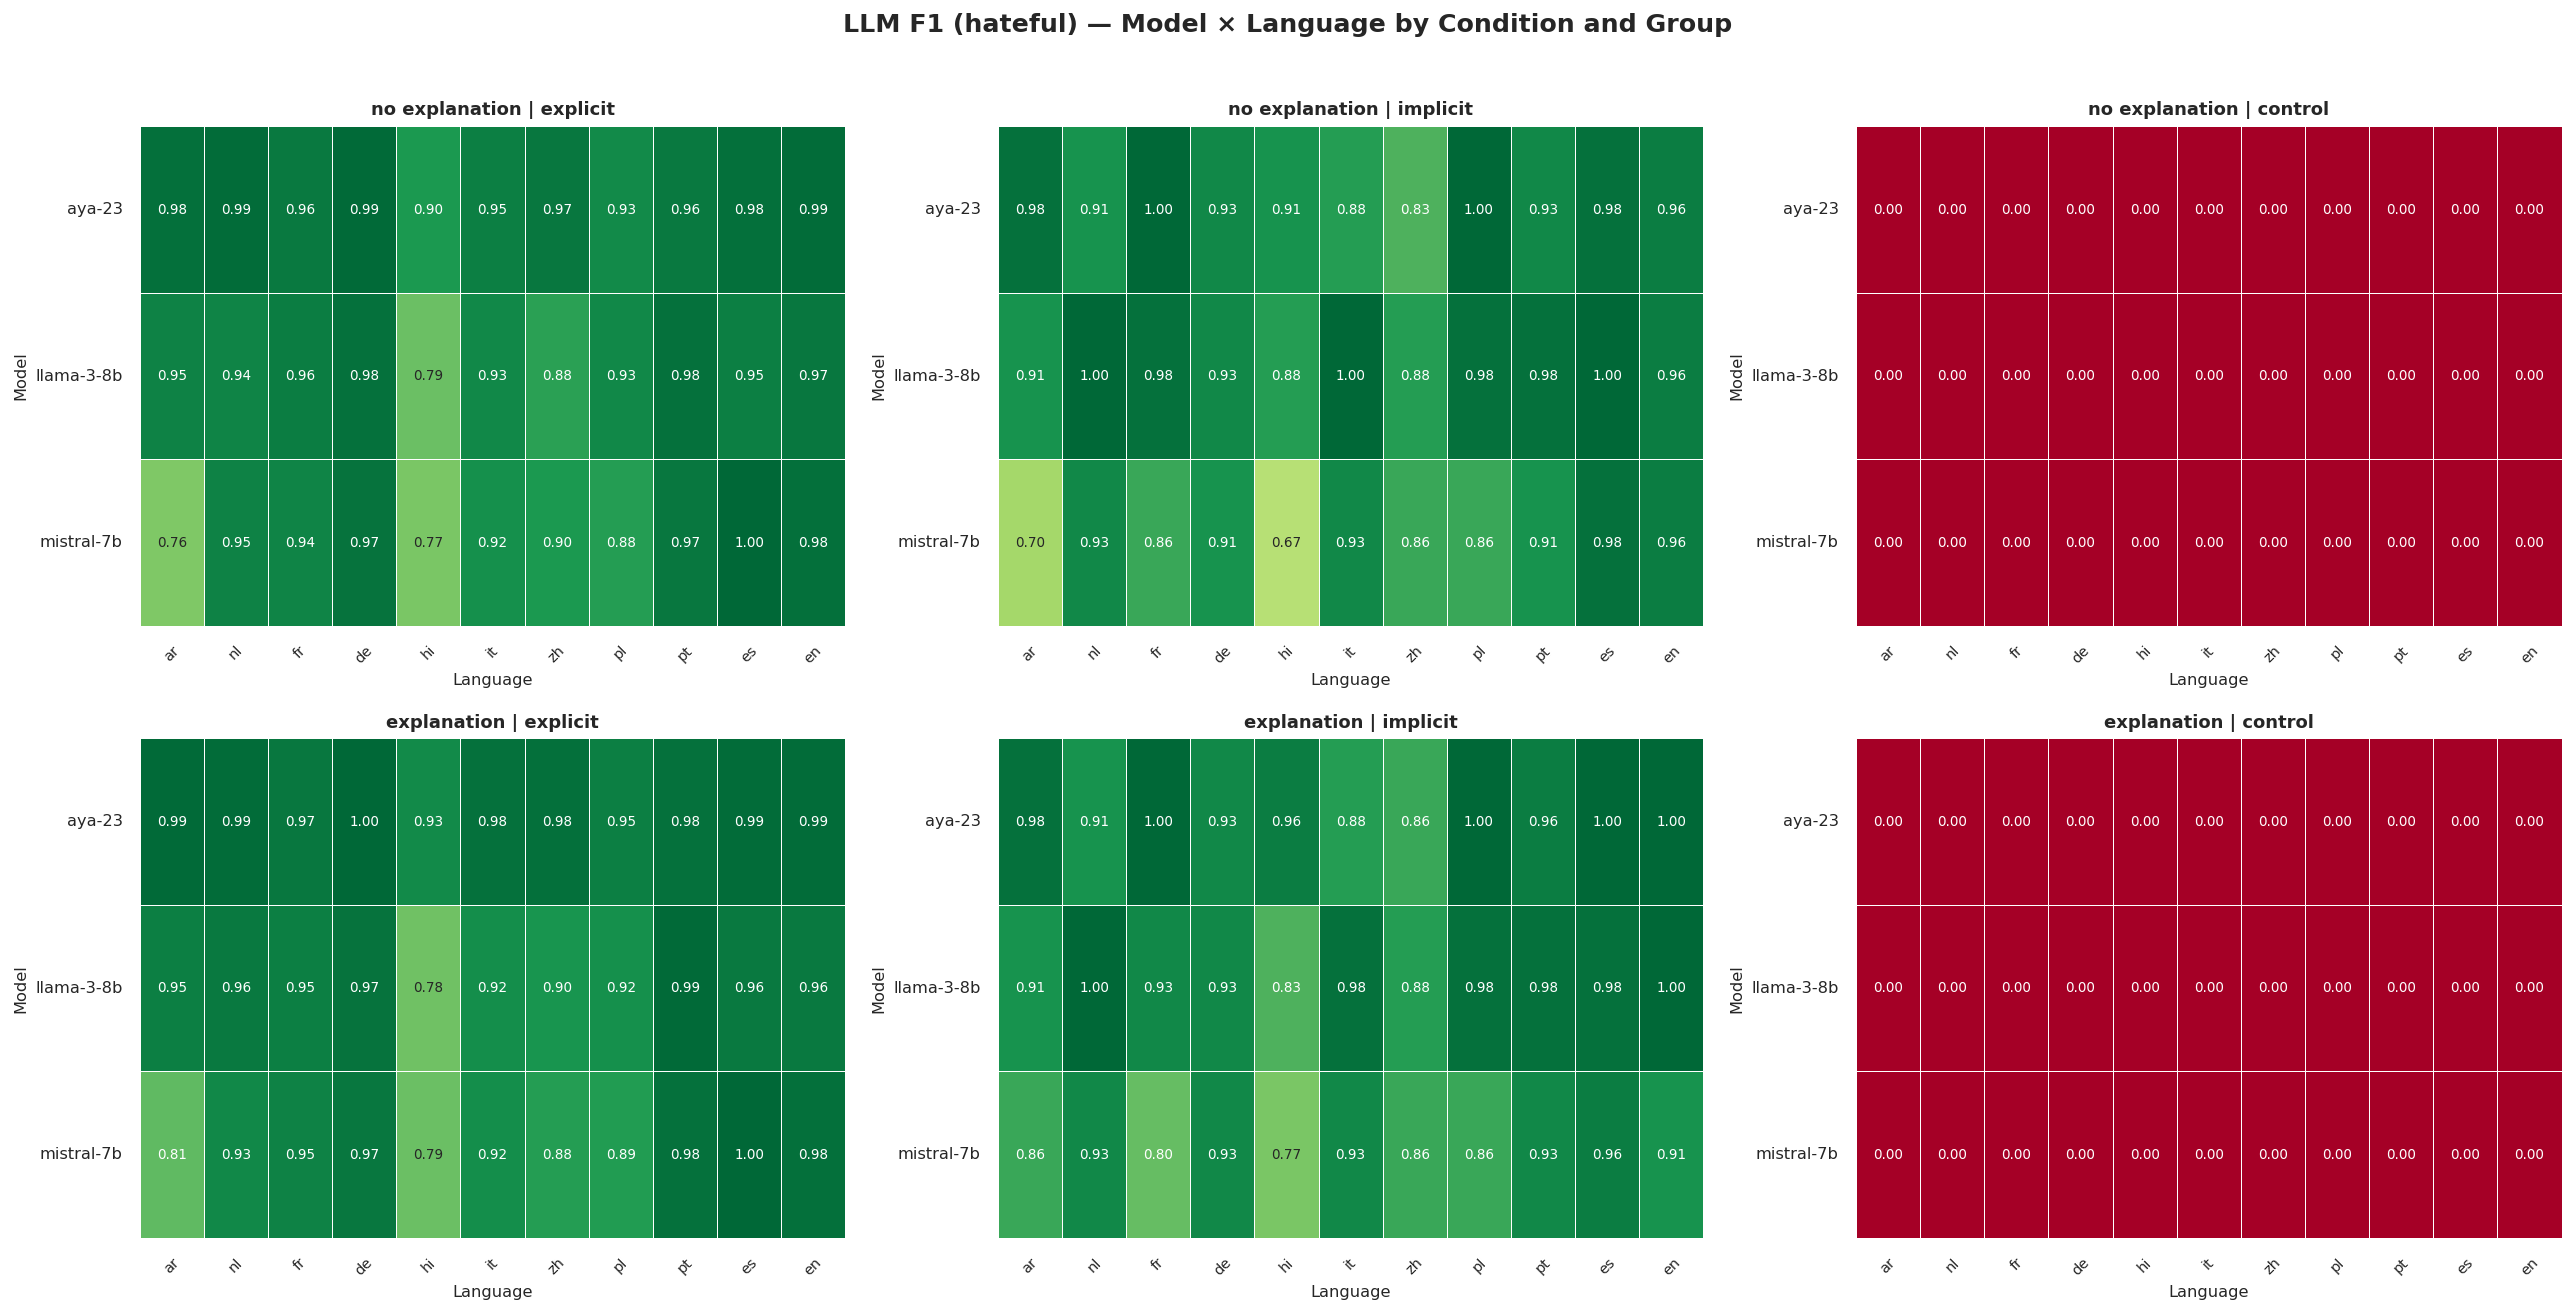

  [saved] outputs/eval/figures/rq3_model_language_heatmap.png


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
combos = [(cond, grp) for cond in COND_ORDER for grp in GROUP_ORDER]

for ax, (cond, grp) in zip(axes.flatten(), combos):
    sub = llm_df[(llm_df["condition"] == cond) & (llm_df["group"] == grp)]
    piv_data = {
        model: {lang: compute_metrics(
            sub[(sub["model"] == model) & (sub["language"] == lang)])["f1"]
            for lang in LANG_ORDER}
        for model in MODEL_ORDER
    }
    piv_hm = pd.DataFrame(piv_data).T.reindex(MODEL_ORDER)[LANG_ORDER]
    sns.heatmap(piv_hm, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
                ax=ax, linewidths=0.3, annot_kws={"size": 7.5}, cbar=False,
                mask=piv_hm.isna())
    ax.set_title(f"{cond.replace('_', ' ')} | {grp}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Language", fontsize=9)
    ax.set_ylabel("Model", fontsize=9)
    ax.set_yticklabels(MODEL_ORDER, rotation=0, fontsize=9)
    ax.set_xticklabels(LANG_ORDER, rotation=45, fontsize=8)

fig.suptitle("LLM F1 (hateful) — Model × Language by Condition and Group", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("rq3_model_language_heatmap")

### 3.3 Demo Selection Strategy Comparison (RQ3.4)

=== Demo Selection Strategy Comparison (no_explanation condition) ===


selection            random    bm25  target_group
model      group                                 
aya-23     control   0.0000  0.0000        0.0000
           explicit  0.9677  0.9647        0.9632
           implicit  0.9647  0.9268        0.9268
llama-3-8b control   0.0000  0.0000        0.0000
           explicit  0.9617  0.9252        0.9153
           implicit  0.9647  0.9461        0.9586
mistral-7b control   0.0000  0.0000        0.0000
           explicit  0.9017  0.9285        0.9219
           implicit  0.8931  0.8790        0.8571

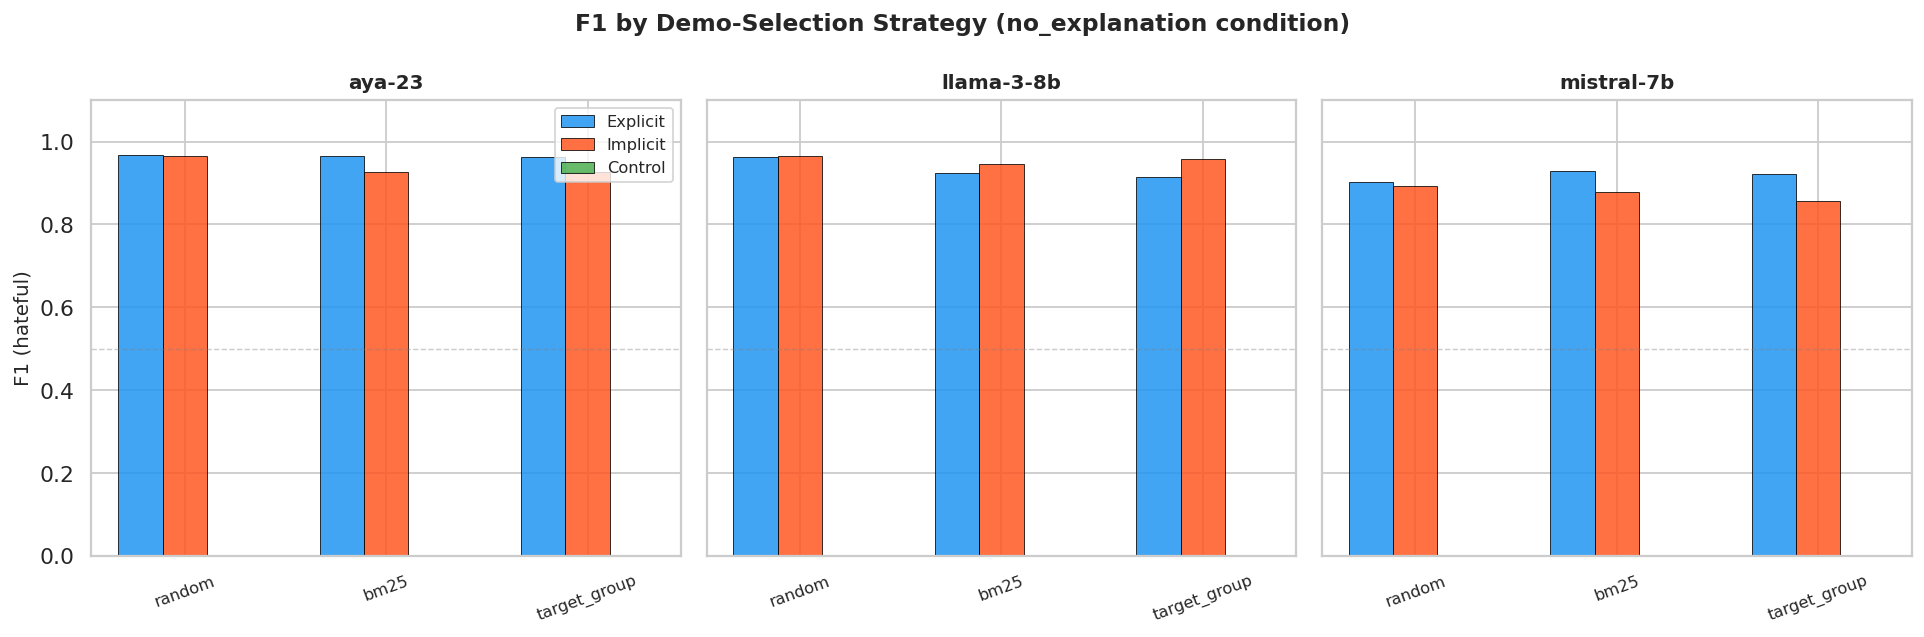

  [saved] outputs/eval/figures/rq3_demo_selection_comparison.png

  McNemar tests: demo selection strategy differences (no_explanation, implicit)


,model,sel_base,sel_test,stat,pvalue,n01,n10,sig
0,aya-23,random,bm25,2.5000,0.113846,2,8,n.s.
1,aya-23,random,target_group,2.5000,0.113846,2,8,n.s.
2,aya-23,bm25,target_group,0.1667,0.683091,3,3,n.s.
3,llama-3-8b,random,bm25,0.5714,0.449692,2,5,n.s.
4,llama-3-8b,random,target_group,0.0000,1.000000,2,3,n.s.
5,llama-3-8b,bm25,target_group,0.5000,0.479500,2,0,n.s.
6,mistral-7b,random,bm25,0.0833,0.772830,5,7,n.s.
7,mistral-7b,random,target_group,1.2308,0.267257,4,9,n.s.
8,mistral-7b,bm25,target_group,0.5714,0.449692,2,5,n.s.


In [17]:
sel_rows = []
for model in MODEL_ORDER:
    for sel in SEL_ORDER:
        for cond in COND_ORDER:
            sub = llm_df[(llm_df["model"] == model) & (llm_df["selection"] == sel) & (llm_df["condition"] == cond)]
            if len(sub) == 0:
                continue
            for grp in GROUP_ORDER:
                mg = compute_metrics(sub[sub["group"] == grp])
                sel_rows.append({"model": model, "selection": sel, "condition": cond,
                                   "group": grp, "f1": round(mg["f1"], 4), "n": mg["n"]})
sel_df = pd.DataFrame(sel_rows)

# Focus: no_explanation condition (cleanest view of selection effect)
sel_no_expl = sel_df[sel_df["condition"] == "no_explanation"]
piv_sel = sel_no_expl.pivot_table(index=["model", "group"], columns="selection", values="f1")[SEL_ORDER]
print("=== Demo Selection Strategy Comparison (no_explanation condition) ===")
display(piv_sel.round(4))

fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(15, 5), sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    sub = sel_no_expl[sel_no_expl["model"] == model]
    x = np.arange(len(SEL_ORDER))
    w = 0.22
    for i, grp in enumerate(GROUP_ORDER):
        grp_sub = sub[sub["group"] == grp].set_index("selection").reindex(SEL_ORDER)
        vals = grp_sub["f1"].values
        ax.bar(x + (i - 1) * w, vals, width=w, label=grp.capitalize(),
                color=GROUP_COLORS[grp], alpha=0.85, edgecolor="black", linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(SEL_ORDER, fontsize=9, rotation=20)
    ax.set_title(model, fontsize=11, fontweight="bold")
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.4, linewidth=0.8)
    if ax == axes[0]:
        ax.set_ylabel("F1 (hateful)", fontsize=11)
        ax.legend(fontsize=9)

fig.suptitle("F1 by Demo-Selection Strategy (no_explanation condition)", fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig("rq3_demo_selection_comparison")

# McNemar: bm25 vs random and target_group vs random (on implicit examples)
print("\n  McNemar tests: demo selection strategy differences (no_explanation, implicit)")
mc_sel_rows = []
for model in MODEL_ORDER:
    for (sel_a, sel_b) in [("random", "bm25"), ("random", "target_group"), ("bm25", "target_group")]:
        base = llm_df[(llm_df["model"] == model) & (llm_df["selection"] == sel_a) &
                       (llm_df["condition"] == "no_explanation") & (llm_df["group"] == "implicit")]
        test = llm_df[(llm_df["model"] == model) & (llm_df["selection"] == sel_b) &
                       (llm_df["condition"] == "no_explanation") & (llm_df["group"] == "implicit")]
        res = run_mcnemar(base, test)
        mc_sel_rows.append({"model": model, "sel_base": sel_a, "sel_test": sel_b,
                              **res, "sig": sig_stars(res["pvalue"])})

mc_sel_df = pd.DataFrame(mc_sel_rows)
display(mc_sel_df[["model", "sel_base", "sel_test", "stat", "pvalue", "n01", "n10", "sig"]])

### 3.4 Friedman Test + Post-hoc Wilcoxon (Multi-model, same examples)

In [18]:
print("=" * 72)
print("  RQ3 Statistical Tests — Multi-model Comparison")
print("  Friedman (k-way repeated measures) + pairwise Wilcoxon (post-hoc)")
print("  Using bm25 selection (consistent across models)")
print("=" * 72)

friedman_rows = []
wilcoxon_rows = []

for cond in COND_ORDER:
    for grp_filter in GROUP_ORDER + ["all"]:
        # Collect per-example correct scores for each model, aligned on shared example_ids
        aligned = {}
        for model in MODEL_ORDER:
            sub = llm_df[(llm_df["model"] == model) & (llm_df["condition"] == cond) & (llm_df["selection"] == "bm25")]
            if grp_filter != "all":
                sub = sub[sub["group"] == grp_filter]
            aligned[model] = sub.set_index("example_id")["correct"]

        common_ids = set(aligned[MODEL_ORDER[0]].index)
        for m in MODEL_ORDER[1:]:
            common_ids &= set(aligned[m].index)
        common_ids = sorted(common_ids)
        n_common = len(common_ids)

        if n_common < 5:
            continue

        matrices = [aligned[m].reindex(common_ids).values.astype(float) for m in MODEL_ORDER]

        accs = {m: matrices[i].mean() for i, m in enumerate(MODEL_ORDER)}
        stat_f, p_f = friedmanchisquare(*matrices)
        sig_f = sig_stars(p_f)
        print(f"\n  [{cond} | {grp_filter}]  n_examples={n_common}")
        for m, acc in accs.items():
            print(f"    {m}: acc={acc:.4f}")
        print(f"  Friedman: chi2={stat_f:.3f}, p={p_f:.4e} {sig_f}")

        friedman_rows.append({"condition": cond, "group": grp_filter, "n": n_common,
                               "friedman_chi2": round(stat_f, 3), "p_friedman": round(p_f, 6),
                               "sig": sig_f, **{m: round(v, 4) for m, v in accs.items()}})

        if p_f < 0.05:
            print("  Pairwise Wilcoxon (post-hoc):")
            for m1, m2 in combinations(MODEL_ORDER, 2):
                a = aligned[m1].reindex(common_ids).values.astype(float)
                b = aligned[m2].reindex(common_ids).values.astype(float)
                if np.all(a == b):
                    continue
                try:
                    w_stat, p_w = wilcoxon(a, b, zero_method="zsplit")
                    sw = sig_stars(p_w)
                    print(f"    {m1} vs {m2}: W={w_stat:.0f}, p={p_w:.4e} {sw}")
                    wilcoxon_rows.append({"condition": cond, "group": grp_filter,
                                           "model_a": m1, "model_b": m2,
                                           "W": round(w_stat, 0), "p_wilcoxon": round(p_w, 6), "sig": sw})
                except ValueError as e:
                    print(f"    {m1} vs {m2}: skipped ({e})")

friedman_df  = pd.DataFrame(friedman_rows) if friedman_rows else pd.DataFrame()
wilcoxon_df  = pd.DataFrame(wilcoxon_rows) if wilcoxon_rows else pd.DataFrame()

  RQ3 Statistical Tests — Multi-model Comparison
  Friedman (k-way repeated measures) + pairwise Wilcoxon (post-hoc)
  Using bm25 selection (consistent across models)

  [no_explanation | explicit]  n_examples=352
    aya-23: acc=0.9318
    llama-3-8b: acc=0.8608
    mistral-7b: acc=0.8665
  Friedman: chi2=18.094, p=1.1776e-04 ***
  Pairwise Wilcoxon (post-hoc):
    aya-23 vs llama-3-8b: W=26902, p=1.6429e-02 *
    aya-23 vs mistral-7b: W=27269, p=2.9654e-02 *
    llama-3-8b vs mistral-7b: W=30734, p=8.4965e-01 n.s.

  [no_explanation | implicit]  n_examples=88
    aya-23: acc=0.8636
    llama-3-8b: acc=0.8977
    mistral-7b: acc=0.7841
  Friedman: chi2=6.583, p=3.7192e-02 *
  Pairwise Wilcoxon (post-hoc):
    aya-23 vs llama-3-8b: W=1835, p=5.7817e-01 n.s.
    aya-23 vs mistral-7b: W=1682, p=2.1980e-01 n.s.
    llama-3-8b vs mistral-7b: W=1556, p=7.1575e-02 n.s.

  [no_explanation | control]  n_examples=88
    aya-23: acc=0.8636
    llama-3-8b: acc=0.8864
    mistral-7b: acc=0.9545
  

### 3.5 Encoder vs Best LLM Comparison

In [19]:
print("=== Encoder vs Best LLM (no_explanation, best selection per model) ===\n")

_llm_7lang_ids = set(llm_df[llm_df["language"].isin(ENC_LANGS)]["example_id"].unique())
enc_shared = enc_df[enc_df["example_id"].isin(_llm_7lang_ids)]
print(f"  Encoder restricted to {len(enc_shared)} shared examples ")

compare_rows = [{"system": "XLM-RoBERTa", "condition": "encoder", "selection": "—",
                  **{grp: round(compute_metrics(enc_shared[enc_shared["group"] == grp])["f1"], 4)
                     for grp in GROUP_ORDER}}]

for model in MODEL_ORDER:
    for sel in SEL_ORDER:
        for cond in COND_ORDER:
            sub = llm_df[(llm_df["model"] == model) & (llm_df["selection"] == sel) & (llm_df["condition"] == cond)]
            if len(sub) == 0:
                continue
            compare_rows.append({"system": model, "condition": cond, "selection": sel,
                                   **{grp: round(compute_metrics(sub[sub["group"] == grp])["f1"], 4)
                                      for grp in GROUP_ORDER}})

enc_vs_llm = pd.DataFrame(compare_rows).set_index(["system", "condition", "selection"])
display(enc_vs_llm[GROUP_ORDER].sort_values("implicit", ascending=False))

=== Encoder vs Best LLM (no_explanation, best selection per model) ===

  Encoder restricted to 336 shared examples 


explicit  implicit  control
system      condition      selection                                
aya-23      explanation    random          0.9753    0.9767      0.0
llama-3-8b  explanation    random          0.9617    0.9708      0.0
aya-23      no_explanation random          0.9677    0.9647      0.0
llama-3-8b  no_explanation random          0.9617    0.9647      0.0
                           target_group    0.9153    0.9586      0.0
aya-23      explanation    bm25            0.9797    0.9524      0.0
llama-3-8b  explanation    target_group    0.9169    0.9461      0.0
            no_explanation bm25            0.9252    0.9461      0.0
aya-23      explanation    target_group    0.9782    0.9333      0.0
llama-3-8b  explanation    bm25            0.9317    0.9268      0.0
aya-23      no_explanation bm25            0.9647    0.9268      0.0
                           target_group    0.9632    0.9268      0.0
mistral-7b  explanation    random          0.9268    0.9136      0.0
            no_explanation random          0.9017    0.8931      0.0
                           bm25            0.9285    0.8790      0.0
            explanation    bm25            0.9235    0.8790      0.0
                           target_group    0.9169    0.8718      0.0
            no_explanation target_group    0.9219    0.8571      0.0
XLM-RoBERTa encoder        —               0.8744    0.5263      0.0

## Section 4 — RQ2.3: Explanation Quality (BERTScore)

BERTScore F1 between generated rationale and input text (reference-free groundedness proxy).

In [20]:
# Install bert-score into the current kernel if not already present.
# Safe to re-run; skips silently if already installed.
%pip install -q bert-score

BERTScore Analysis
  Scoring 4,752 explanations with bert-base-multilingual-cased …


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


  BERTScore F1 (explanation groundedness) by model × group:


group,control,explicit,implicit
model,,,
aya-23,0.6302,0.6632,0.6607
llama-3-8b,0.6249,0.6537,0.6525
mistral-7b,0.6207,0.6562,0.6520


,model,group,n,mean_bs,bs_correct,bs_incorrect
0,aya-23,explicit,1056,0.6632,0.6652,0.6199
1,aya-23,implicit,264,0.6607,0.6633,0.6338
2,aya-23,control,264,0.6302,0.6259,0.6418
3,llama-3-8b,explicit,1056,0.6537,0.6581,0.6207
4,llama-3-8b,implicit,264,0.6525,0.6562,0.6186
5,llama-3-8b,control,264,0.6249,0.6230,0.6371
6,mistral-7b,explicit,1056,0.6562,0.6628,0.6174
7,mistral-7b,implicit,264,0.6520,0.6604,0.6185
8,mistral-7b,control,264,0.6207,0.6191,0.6446



  Point-biserial r (BERTScore vs correctness) per model:
    aya-23: r=0.1896, p=2.7447e-14 ***  (n=1584)
    llama-3-8b: r=0.2509, p=3.6267e-24 ***  (n=1584)
    mistral-7b: r=0.3150, p=7.9000e-38 ***  (n=1584)


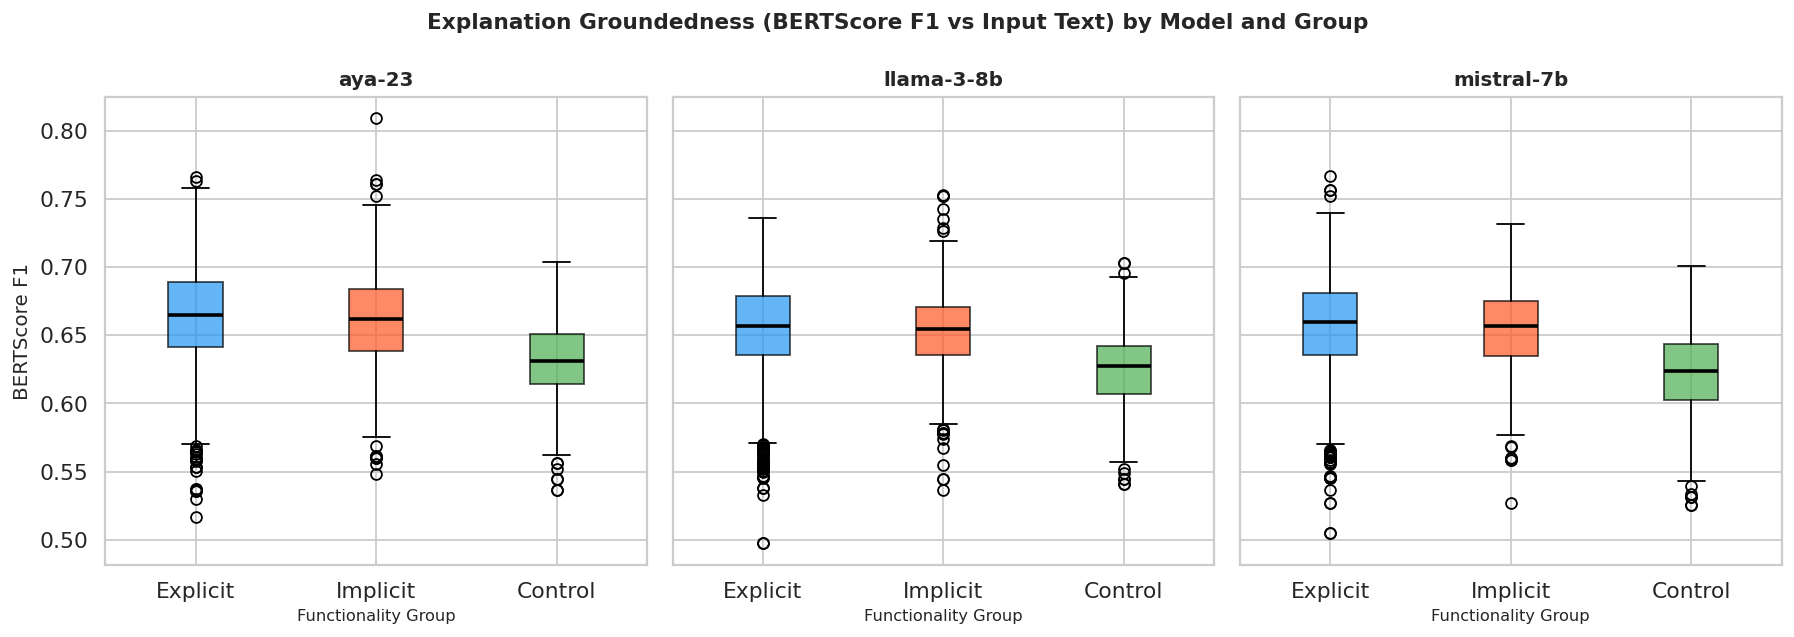

  [saved] outputs/eval/figures/rq2_bertscore_by_model_group.png
  BERTScore results saved to outputs/eval/


In [21]:
print("BERTScore Analysis")

try:
    from bert_score import score as bertscore
    from transformers import logging as hf_logging
    hf_logging.set_verbosity_error()

    _BERT_MODEL = "bert-base-multilingual-cased"

    expl_sub = llm_df[
        (llm_df["condition"] == "explanation") &
        (~llm_df["parse_fail"]) &
        (llm_df["rationale"].notna())
    ].copy()
    expl_sub["gold_text"] = expl_sub["example_id"].map(lambda eid: gold[eid].text if eid in gold else None)
    expl_sub = expl_sub[expl_sub["gold_text"].notna()].reset_index(drop=True)

    print(f"  Scoring {len(expl_sub):,} explanations with {_BERT_MODEL} …")
    _, _, f1_scores = bertscore(
        expl_sub["rationale"].tolist(), expl_sub["gold_text"].tolist(),
        model_type=_BERT_MODEL, num_layers=9, verbose=False, batch_size=64,
    )
    expl_sub["bertscore_f1"] = f1_scores.tolist()

    # Aggregate per model × group
    def _mean(s):
        return s.mean() if len(s) > 0 else np.nan

    agg_bs = []
    for model in MODEL_ORDER:
        for grp in GROUP_ORDER:
            sub = expl_sub[(expl_sub["model"] == model) & (expl_sub["group"] == grp)]
            corr_sub = sub[sub["correct"] == 1]["bertscore_f1"]
            incorr_sub = sub[sub["correct"] == 0]["bertscore_f1"]
            agg_bs.append({"model": model, "group": grp, "n": len(sub),
                            "mean_bs": round(_mean(sub["bertscore_f1"]), 4),
                            "bs_correct": round(_mean(corr_sub), 4),
                            "bs_incorrect": round(_mean(incorr_sub), 4)})
    bs_agg_df = pd.DataFrame(agg_bs)
    print("\n  BERTScore F1 (explanation groundedness) by model × group:")
    display(bs_agg_df.pivot(index="model", columns="group", values="mean_bs").round(4))
    display(bs_agg_df)

    # Point-biserial correlation (BS vs correctness) per model
    print("\n  Point-biserial r (BERTScore vs correctness) per model:")
    corr_rows = []
    for model in MODEL_ORDER:
        sub = expl_sub[expl_sub["model"] == model]
        if len(sub) < 10 or len(sub["correct"].unique()) < 2:
            continue
        r, p = pointbiserialr(sub["correct"].values, sub["bertscore_f1"].values)
        sw = sig_stars(p)
        print(f"    {model}: r={r:.4f}, p={p:.4e} {sw}  (n={len(sub)})")
        corr_rows.append({"model": model, "n": len(sub), "r": round(r, 4), "p": round(p, 6), "sig": sw})
    bs_corr_df = pd.DataFrame(corr_rows)

    # Box plot: BERTScore distributions
    fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(14, 5), sharey=True)
    for ax, model in zip(axes, MODEL_ORDER):
        data = [expl_sub[(expl_sub["model"] == model) & (expl_sub["group"] == grp)]["bertscore_f1"].dropna().values
                for grp in GROUP_ORDER]
        bp = ax.boxplot(data, labels=[g.capitalize() for g in GROUP_ORDER],
                         patch_artist=True, notch=False, medianprops={"color": "black", "linewidth": 2})
        for patch, grp in zip(bp["boxes"], GROUP_ORDER):
            patch.set_facecolor(GROUP_COLORS[grp])
            patch.set_alpha(0.7)
        ax.set_title(model, fontsize=11, fontweight="bold")
        ax.set_xlabel("Functionality Group", fontsize=9)
        if ax == axes[0]:
            ax.set_ylabel("BERTScore F1", fontsize=11)
    fig.suptitle("Explanation Groundedness (BERTScore F1 vs Input Text) by Model and Group",
                 fontsize=12, fontweight="bold")
    save_fig("rq2_bertscore_by_model_group")

    # Save
    expl_sub[["example_id", "model", "selection", "group", "language", "correct", "bertscore_f1"]].to_csv(
        OUTPUT_DIR / "bertscore_per_example.csv", index=False)
    bs_agg_df.to_csv(OUTPUT_DIR / "bertscore_aggregated.csv", index=False)
    if corr_rows:
        bs_corr_df.to_csv(OUTPUT_DIR / "bertscore_correctness_correlation.csv", index=False)
    print(f"  BERTScore results saved to {OUTPUT_DIR.relative_to(PROJECT_ROOT)}/")

except ImportError:
    print("  bert-score not installed — skipping. Install with:  pip install bert-score")
except Exception as exc:
    print(f"  BERTScore failed: {exc}")

## Section 5 — Export All Results

In [22]:
# Encoder
metrics_table(enc_df, "functionality").to_csv(OUTPUT_DIR / "encoder_by_functionality.csv", index=False)
metrics_table(enc_df, "language").to_csv(OUTPUT_DIR / "encoder_by_language.csv", index=False)
metrics_table(enc_df, "group").to_csv(OUTPUT_DIR / "encoder_by_group.csv", index=False)
pivot_f1(enc_df, "functionality", "language").to_csv(OUTPUT_DIR / "encoder_f1_heatmap.csv")
gap_df.reset_index().to_csv(OUTPUT_DIR / "encoder_impl_expl_gap_by_language.csv", index=False)
stats_rq1.to_csv(OUTPUT_DIR / "rq1_statistical_tests.csv", index=False)

# LLM
detail_df.to_csv(OUTPUT_DIR / "llm_detailed_metrics.csv", index=False)
summ.to_csv(OUTPUT_DIR / "llm_summary_by_model_condition_group.csv", index=False)
mc_df.to_csv(OUTPUT_DIR / "rq2_mcnemar_explanation_effect.csv", index=False)
mc_sel_df.to_csv(OUTPUT_DIR / "rq3_mcnemar_demo_selection.csv", index=False)
delta_df.to_csv(OUTPUT_DIR / "rq2_explanation_delta.csv", index=False)
sel_df.to_csv(OUTPUT_DIR / "rq3_demo_selection_metrics.csv", index=False)
enc_vs_llm.to_csv(OUTPUT_DIR / "encoder_vs_llm_comparison.csv")

if not friedman_df.empty:
    friedman_df.to_csv(OUTPUT_DIR / "rq3_friedman_test.csv", index=False)
if not wilcoxon_df.empty:
    wilcoxon_df.to_csv(OUTPUT_DIR / "rq3_wilcoxon_posthoc.csv", index=False)

print("\nCSV files saved to outputs/eval/:")
for f in sorted(OUTPUT_DIR.glob("*.csv")):
    print(f"  {f.name}")

print("\nFigures saved to outputs/eval/figures/:")
for f in sorted(FIGURES_DIR.glob("*.png")):
    print(f"  {f.name}")


CSV files saved to outputs/eval/:
  bertscore_aggregated.csv
  bertscore_correctness_correlation.csv
  bertscore_per_example.csv
  encoder_by_functionality.csv
  encoder_by_group.csv
  encoder_by_language.csv
  encoder_f1_heatmap.csv
  encoder_impl_expl_gap_by_language.csv
  encoder_vs_llm_comparison.csv
  llm_detailed_metrics.csv
  llm_summary_by_model_condition_group.csv
  rq1_statistical_tests.csv
  rq2_explanation_delta.csv
  rq2_mcnemar_explanation_effect.csv
  rq3_demo_selection_metrics.csv
  rq3_friedman_test.csv
  rq3_mcnemar_demo_selection.csv
  rq3_wilcoxon_posthoc.csv

Figures saved to outputs/eval/figures/:
  rq1_encoder_by_group.png
  rq1_encoder_by_language.png
  rq1_encoder_heatmap_func_lang.png
  rq1_impl_expl_gap_by_language.png
  rq2_bertscore_by_model_group.png
  rq2_explanation_delta_acc_control.png
  rq2_explanation_delta_by_group.png
  rq2_explanation_delta_by_language.png
  rq3_demo_selection_comparison.png
  rq3_model_language_heatmap.png
